In [ ]:
# A parallel workflow in LangGraph means running multiple tasks at the same time and then combining their results.

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_community.chat_models import ChatOllama

In [14]:
model = ChatOllama(model="llama3", temparature=1.5)

In [15]:
class GraphState(TypedDict):
    text: str
    summary: str
    sentiment: str
    summary_sentiment: str

In [16]:
def get_summary(state: GraphState):
    text = state['text']
    prompt = f"Summarize the following text in 2 lines : {text}"
    summary = model.invoke(prompt).content
    state['summary'] = summary
    return {'summary' : summary}

def get_sentiment(state: GraphState):
    text = state['text']
    prompt = f"Analyze the sentiment of the following text : {text}"
    sentiment = model.invoke(prompt).content
    state['sentiment'] = sentiment
    return {'sentiment' : sentiment}

def get_summary_sentiment(state: GraphState):
    text = state['text']
    summary = state['summary']
    sentiment = state['sentiment']
    prompt = f"Given the following text : {text} with summary : {summary} and sentiment : {sentiment}, Generate a combined summary and sentiment analysis in 2 lines."
    summary_sentiment = model.invoke(prompt).content
    state['summary_sentiment'] = summary_sentiment
    return state


In [17]:
# Create Graph
graph = StateGraph(GraphState)

# Create Nodes
graph.add_node('get_summary', get_summary)
graph.add_node('get_sentiment', get_sentiment)
graph.add_node('get_summary_sentiment', get_summary_sentiment)

# Create Edges
graph.add_edge(START, 'get_summary')
graph.add_edge(START, 'get_sentiment')
graph.add_edge('get_summary', 'get_summary_sentiment')
graph.add_edge('get_sentiment', 'get_summary_sentiment')    
graph.add_edge('get_summary_sentiment', END)

# Compile Graph
workflow = graph.compile()

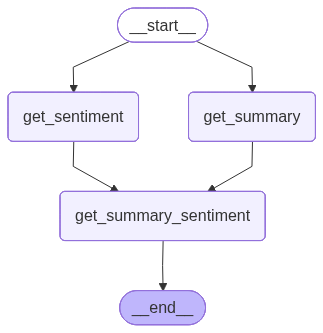

In [18]:
workflow

In [19]:
intial_state = {'text': 'LangGraph is a framework for building stateful AI agents. It helps developers create workflows with branching,loops and parallel execution.'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'text': 'LangGraph is a framework for building stateful AI agents. It helps developers create workflows with branching,loops and parallel execution.', 'summary': 'Here is a 2-line summary of the text:\n\nLangGraph is a framework that enables developers to build stateful AI agents by creating workflows with features like branching, loops, and parallel execution. This allows for more complex and dynamic decision-making processes in artificial intelligence applications.', 'sentiment': "The sentiment of the given text is NEUTRAL.\n\nHere's why:\n\n* The tone is informative and objective, providing a straightforward description of what LangGraph is and what it can do.\n* There are no emotional appeals, rhetorical questions, or sensational language used to elicit a particular response from the reader.\n* The text lacks any negative or critical sentiments, such as complaints, criticisms, or warnings.\n* Similarly, there are no overwhelmingly positive or enthusiastic statements that would sug

In [ ]:
final_state['summary']

'Here is a 2-line summary of the text:\n\nLangGraph is a framework that enables developers to build stateful AI agents by creating workflows with features like branching, loops, and parallel execution. This allows for more complex and dynamic decision-making processes in artificial intelligence applications.'

In [21]:
final_state['sentiment']

"The sentiment of the given text is NEUTRAL.\n\nHere's why:\n\n* The tone is informative and objective, providing a straightforward description of what LangGraph is and what it can do.\n* There are no emotional appeals, rhetorical questions, or sensational language used to elicit a particular response from the reader.\n* The text lacks any negative or critical sentiments, such as complaints, criticisms, or warnings.\n* Similarly, there are no overwhelmingly positive or enthusiastic statements that would suggest an overly optimistic or promotional tone.\n\nOverall, the sentiment of the text is neutral and informative, aimed at providing a factual overview of LangGraph's capabilities."

In [22]:
final_state['summary_sentiment']

"Here is a combined summary and sentiment analysis in 2 lines:\n\nLangGraph is a framework that enables developers to build stateful AI agents by creating workflows with features like branching, loops, and parallel execution. The text has a neutral sentiment, providing an informative overview of LangGraph's capabilities without emotional appeals or sensational language."